<a href="https://colab.research.google.com/github/Tejaswibatchala/Tejaswibatchala/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

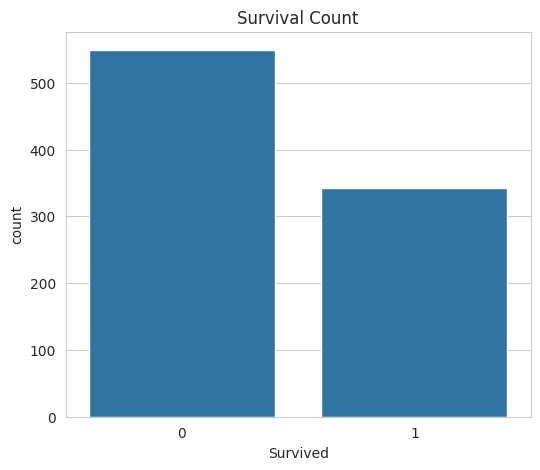

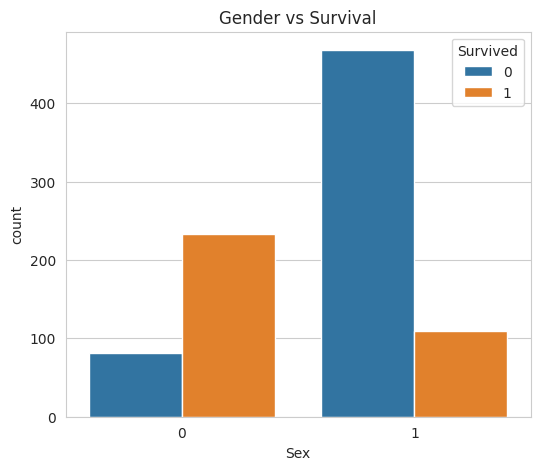

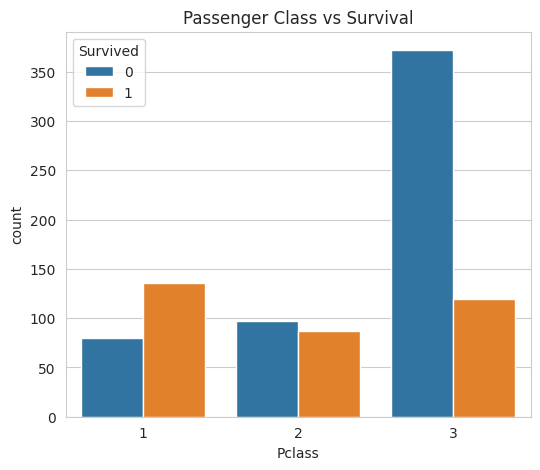

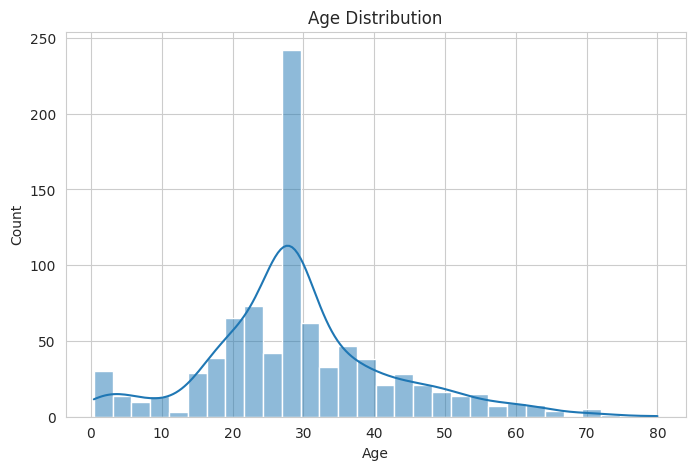

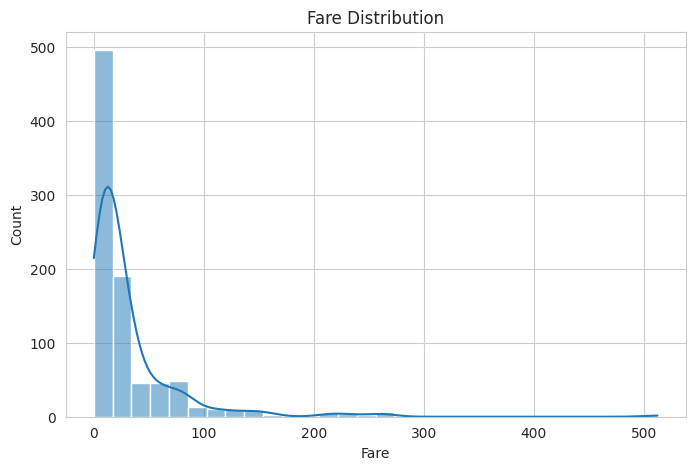

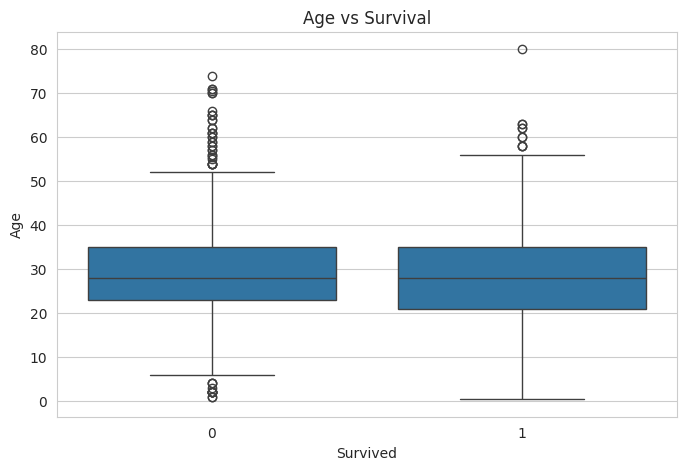

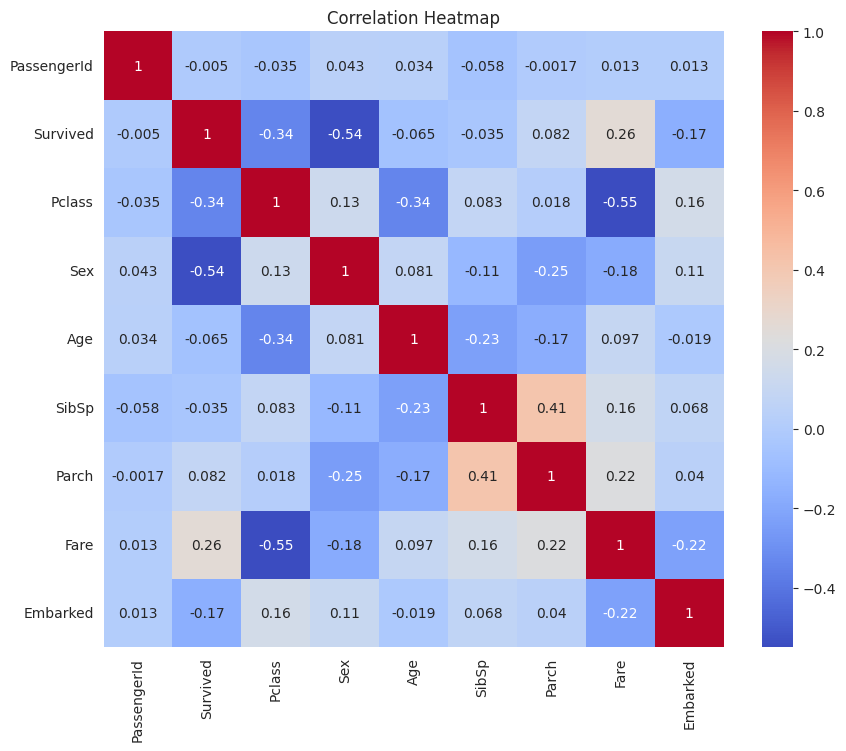

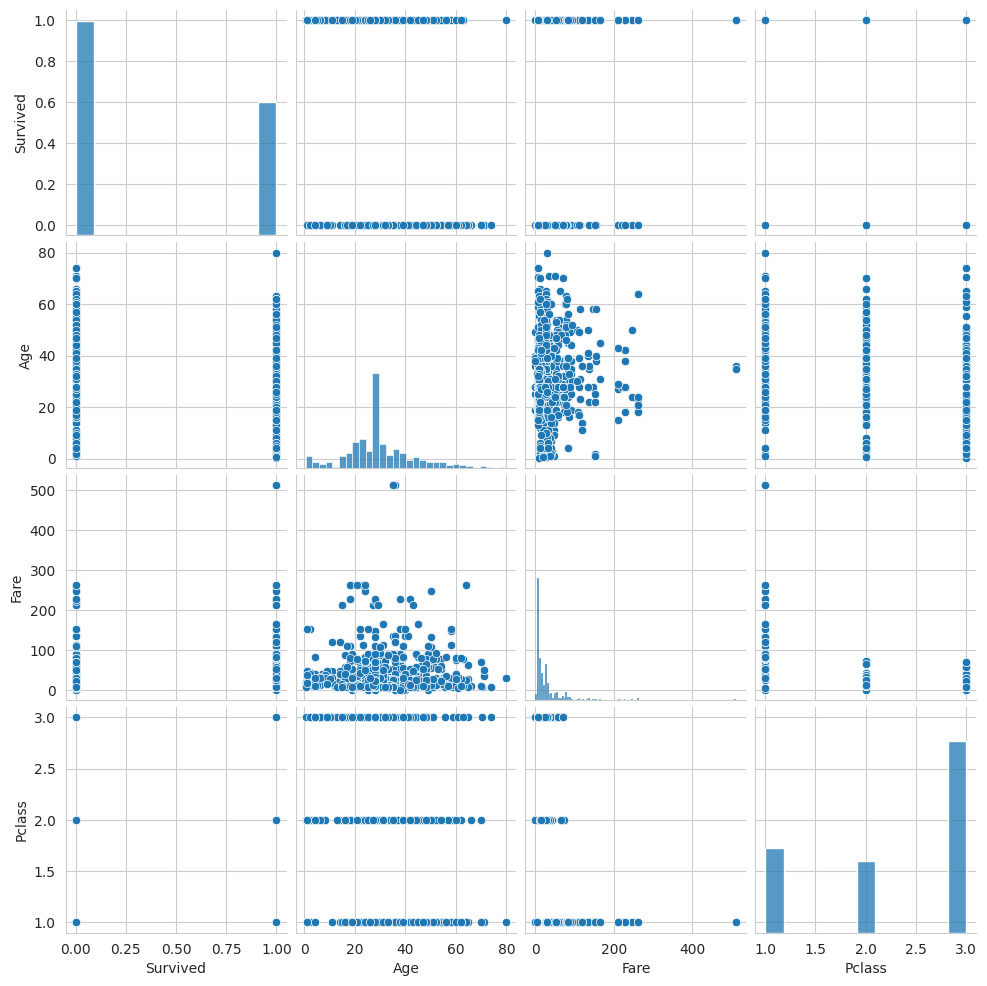



MODEL RESULTS

Logistic Regression
----------------------------------------
Accuracy: 81.01 %

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix
[[90 15]
 [19 55]]

Decision Tree
----------------------------------------
Accuracy: 78.21 %

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179

Confusion Matrix
[[83 22]
 [17 57]]

Random Forest
----------------------------------------
Ac

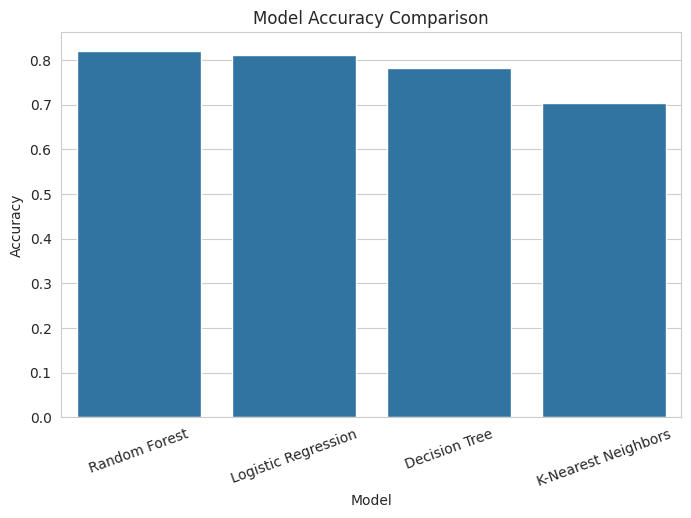

In [2]:
# ==========================================
# TITANIC DATASET - EDA + DATA CLEANING + ML
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------------------------
# Load Dataset
# ----------------------------
df = pd.read_csv("Titanic-Dataset.csv")

print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ----------------------------
# Data Cleaning
# ----------------------------

# Fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fill Fare with median (if any missing)
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Drop Cabin column
df.drop("Cabin", axis=1, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# ----------------------------
# Encode Categorical Variables
# ----------------------------

encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

# ----------------------------
# Exploratory Data Analysis
# ----------------------------

sns.set_style("whitegrid")

# Survival Count
plt.figure(figsize=(6,5))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

# Gender vs Survival
plt.figure(figsize=(6,5))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Gender vs Survival")
plt.show()

# Passenger Class
plt.figure(figsize=(6,5))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Passenger Class vs Survival")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Fare Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age vs Survival")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df[['Survived','Age','Fare','Pclass']])
plt.show()

# ----------------------------
# Prepare Data
# ----------------------------

X = df.drop(["PassengerId", "Name", "Ticket", "Survived"], axis=1)
y = df["Survived"]

# ----------------------------
# Train Test Split
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ----------------------------
# Machine Learning Models
# ----------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

print("\n")
print("=" * 60)
print("MODEL RESULTS")
print("=" * 60)

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy:", round(accuracy * 100, 2), "%")

    print("\nClassification Report")
    print(classification_report(y_test, prediction))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, prediction))

# ----------------------------
# Compare Accuracy
# ----------------------------

accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy_scores[name] = accuracy_score(y_test, pred)

result = pd.DataFrame({
    "Model": accuracy_scores.keys(),
    "Accuracy": accuracy_scores.values()
})

result = result.sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison")
print(result)

plt.figure(figsize=(8,5))
sns.barplot(data=result, x="Model", y="Accuracy")
plt.xticks(rotation=20)
plt.title("Model Accuracy Comparison")
plt.show()